# 10. 최종 모형 (권장 본모형)

01~09의 검토를 종합한 최종 모형이다. 문서 정리본은 `../최종모형.md`에 있다.

## 식
$$
\log E[Y^{2025}_{ir}] = \log Y^{2024}_{ir} + \beta_1 \text{보행20분이내}_i + \beta_2 \text{보행20\sim60분}_i + \beta_3 \text{IC도로거리}_i + \beta_4 \text{경쟁목적지비율}_i + \beta_5 \text{20\sim50대인구}_i + \beta_6 \text{건축물수}_i + \gamma_r
$$

- $i$ = 250m 셀, $r$ = 노선. 단위는 **셀 × 노선** (2024년 승차가 있는 쌍)
- $\log Y^{2024}_{ir}$ = offset (계수 1 고정) → β는 **변화율(2025/2024)에 대한 효과**
- $\gamma_r$ = **노선 고정효과** (24개 노선) → 같은 노선 안에서 비교
- 추정: Poisson (QMLE), **셀 단위 군집 강건 표준오차**
- 해석: $e^{\beta} - 1$ = 변화율 차이(%)
- 본분석은 **오전(07:00~09:59)**, 강건성은 **종일**

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # 정리본 최상위의 config.py

from config import *
setup_notebook()

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = load_model_data()
X_FINAL = ["walk_20", "walk_20_60", "ic_access", "competing_share", "pop_20_50", "buildings"]
trips = load_trips().dropna(subset=["셀 ID"])
HOURS = {"오전(07~09시)": MORNING_HOURS, "종일": ALL_DAY_HOURS}


def build_pairs(hours):
    frame = (trips[trips["시"].between(*hours)]
             .pivot_table(index=["셀 ID", "노선"], columns="연도", values="승차인원", aggfunc="sum", fill_value=0)
             .reset_index().rename(columns={2024: "y2024", 2025: "y2025"}))
    frame["셀 ID"] = frame["셀 ID"].astype(int)
    frame = frame.merge(data[["셀 ID"] + X_FINAL], on="셀 ID")
    return frame[frame.y2024 > 0].reset_index(drop=True)


pairs = {name: build_pairs(hours) for name, hours in HOURS.items()}
for name, frame in pairs.items():
    print(f"{name}: 셀×노선 {len(frame)}쌍, 셀 {frame['셀 ID'].nunique()}개, 노선 {frame.노선.nunique()}개, "
          f"승차 {frame.y2024.sum():,.0f} → {frame.y2025.sum():,.0f}명")

오전(07~09시): 셀×노선 186쌍, 셀 118개, 노선 24개, 승차 6,044 → 4,682명
종일: 셀×노선 220쌍, 셀 132개, 노선 24개, 승차 19,884 → 16,300명


## 추정 결과

In [3]:
results, tables = {}, {}
for name, frame in pairs.items():
    X = pd.concat([frame[X_FINAL], pd.get_dummies(frame.노선, prefix="노선", drop_first=True, dtype=float)], axis=1)
    result = poisson_rate(frame.y2025, frame.y2024, X, cluster=frame["셀 ID"])
    ci = result.conf_int().loc[X_FINAL]
    table = pd.DataFrame({
        "β": result.params[X_FINAL],
        "변화율 차이(%)": (np.exp(result.params[X_FINAL]) - 1) * 100,
        "95% CI 하한(%)": (np.exp(ci[0]) - 1) * 100,
        "95% CI 상한(%)": (np.exp(ci[1]) - 1) * 100,
        "p": result.pvalues[X_FINAL],
    })
    table["유의"] = np.select([table.p < 0.01, table.p < 0.05, table.p < 0.1], ["***", "**", "*"], "")
    table.index = [VARIABLE_LABELS[c] for c in X_FINAL]
    results[name], tables[name] = result, table.round(4)
    null = sm.GLM(frame.y2025, np.ones((len(frame), 1)), family=sm.families.Poisson(), offset=np.log(frame.y2024)).fit()
    print(f"{name}: N={len(frame)}, deviance 설명비율(pseudo R2) = {1 - result.deviance / null.deviance:.3f}")
pd.concat(tables, axis=1)

오전(07~09시): N=186, deviance 설명비율(pseudo R2) = 0.424
종일: N=220, deviance 설명비율(pseudo R2) = 0.478


오전(07~09시)                                                       종일                                                 
                          β 변화율 차이(%) 95% CI 하한(%) 95% CI 상한(%)       p   유의       β 변화율 차이(%) 95% CI 하한(%) 95% CI 상한(%)       p   유의
보행 20분 이내           -0.5755  -43.7566     -61.4194     -18.0076  0.0028  *** -0.9257  -60.3744     -72.4630     -42.9790  0.0000  ***
보행 20~60분           -0.1887  -17.1945     -36.4835       7.9522  0.1632      -0.2870  -24.9457     -40.3331      -5.5900  0.0142   **
IC까지 도로거리(km)       -0.1139  -10.7675     -17.9522      -2.9536  0.0078  *** -0.0585   -5.6819     -10.0983      -1.0485  0.0168   **
GTX 경쟁 목적지 비율(%)    -0.0048   -0.4788      -1.3654       0.4158  0.2932      -0.0027   -0.2711      -1.0188       0.4823  0.4796     
2024년 20~50대 인구     -0.0001   -0.0066      -0.0380       0.0247  0.6775       0.0002    0.0192      -0.0062       0.0445  0.1388     
2024년 건축물 수         -0.0014   -0.1372      -0.7599       0.4895  0.6671      -0.0007   -0.0713      -0.4940       0.3532  0.7415

> pseudo R²에는 노선 고정효과의 설명분도 들어 있어서, 셀 변수만의 설명력이 아니다. 이 연구는 계수의 방향·크기·유의성을 중심으로 보고한다.

## 다중공선성 (VIF, 노선 더미 포함 설계행렬 기준)

In [4]:
vif = {}
for name, frame in pairs.items():
    X = sm.add_constant(pd.concat([frame[X_FINAL], pd.get_dummies(frame.노선, prefix="노선", drop_first=True, dtype=float)], axis=1))
    vif[name] = pd.Series({VARIABLE_LABELS[c]: variance_inflation_factor(X.values, list(X.columns).index(c)) for c in X_FINAL})
pd.DataFrame(vif).round(2)

,오전(07~09시),종일
보행 20분 이내,3.15,2.73
보행 20~60분,3.95,3.40
IC까지 도로거리(km),2.68,2.72
GTX 경쟁 목적지 비율(%),2.25,2.04
2024년 20~50대 인구,1.62,1.55
2024년 건축물 수,1.42,1.29


## 결론
- 핵심 변수 두 개가 오전·종일 모두 유의하다:
  - **GTX 보행 20분 이내**: 오전 −44%, 종일 −60%
  - **IC까지 도로거리**: 1km당 오전 −11%, 종일 −6%
- 보행 20~60분은 종일에서만 유의하다. 경쟁 목적지 비율, 20~50대 인구, 건축물 수는 유의하지 않다.
- VIF는 모두 4 미만이라 다중공선성 문제는 없다.

## 최종모형 식과 조정 예측 시각화

아래 그래프는 각 변수를 따로 회귀한 결과가 아니다. 모든 설명변수와 노선 고정효과를 동시에 포함한 최종 Poisson 모형에서, 관심 변수만 변화시키고 나머지는 실제 표본값으로 유지한 조정 예측값이다.

$$\log E(Y^{2025}_{ir}) = \log(Y^{2024}_{ir}) + \beta_1 GTX20_i + \beta_2 GTX20\text{-}60_i + \beta_3 IC거리_i + \beta_4 경쟁목적지비율_i + \beta_5 인구_i + \beta_6 건축물_i + \gamma_r$$

- `Y2025`: 셀×노선별 2025년 승차인원
- `log(Y2024)`: offset으로 계수 1을 고정
- `γr`: 노선 고정효과
- 결과값: 예측 승차인원 자체가 아니라 `예측 2025 / 2024 - 1`의 변화율

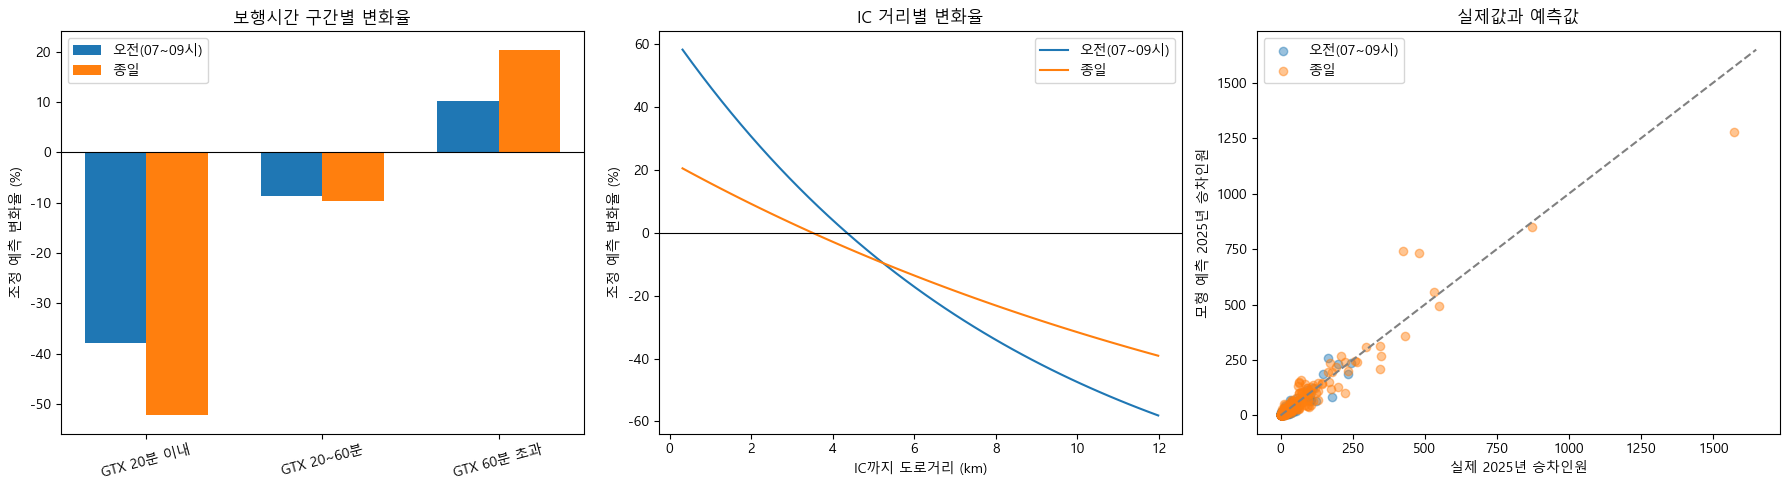

In [5]:
import matplotlib.pyplot as plt

def prediction_design(frame, result, overrides=None):
    x = frame[X_FINAL].copy()
    if overrides:
        for col, value in overrides.items():
            x[col] = value
    route_dummies = pd.get_dummies(frame['노선'], prefix='노선', drop_first=True, dtype=float)
    x = pd.concat([x, route_dummies], axis=1)
    x = sm.add_constant(x, has_constant='add')
    return x.reindex(columns=result.model.exog_names, fill_value=0)

def adjusted_rate(frame, result, overrides=None):
    exog = prediction_design(frame, result, overrides)
    predicted = result.predict(exog=exog, offset=np.log(frame['y2024']))
    return float(np.mean(predicted / frame['y2024'] - 1) * 100)

# 모든 변수를 포함한 최종모형의 조정 예측값
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 보행시간 구간별 조정 예측 변화율
walk_labels = ['GTX 20분 이내', 'GTX 20~60분', 'GTX 60분 초과']
walk_overrides = [
    {'walk_20': 1, 'walk_20_60': 0},
    {'walk_20': 0, 'walk_20_60': 1},
    {'walk_20': 0, 'walk_20_60': 0},
]
for name, result in results.items():
    frame = pairs[name]
    vals = [adjusted_rate(frame, result, ov) for ov in walk_overrides]
    axes[0].bar(np.arange(3) + (0.35 if name == '종일' else 0), vals, width=0.35, label=name)
axes[0].set_xticks(np.arange(3) + 0.175)
axes[0].set_xticklabels(walk_labels, rotation=15)
axes[0].set_ylabel('조정 예측 변화율 (%)')
axes[0].set_title('보행시간 구간별 변화율')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].legend()

# 2) IC 거리별 조정 예측 변화율
for name, result in results.items():
    frame = pairs[name]
    grid = np.linspace(frame['ic_access'].min(), frame['ic_access'].max(), 50)
    vals = [adjusted_rate(frame, result, {'ic_access': value}) for value in grid]
    axes[1].plot(grid, vals, label=name)
axes[1].set_xlabel('IC까지 도로거리 (km)')
axes[1].set_ylabel('조정 예측 변화율 (%)')
axes[1].set_title('IC 거리별 변화율')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].legend()

# 3) 실제 2025년 승차인원과 최종모형 예측값
for name, result in results.items():
    frame = pairs[name]
    exog = prediction_design(frame, result)
    pred = result.predict(exog=exog, offset=np.log(frame['y2024']))
    axes[2].scatter(frame['y2025'], pred, alpha=0.45, label=name)
limit = max(axes[2].get_xlim()[1], axes[2].get_ylim()[1])
axes[2].plot([0, limit], [0, limit], '--', color='gray')
axes[2].set_xlabel('실제 2025년 승차인원')
axes[2].set_ylabel('모형 예측 2025년 승차인원')
axes[2].set_title('실제값과 예측값')
axes[2].legend()

plt.tight_layout()
plt.show()